# Task 4.1 — Factor-Return Backtesting Analytics

Per-category return analysis with train/val/test time splits, Sharpe ratios,
t-statistics, cumulative return charts, and rolling t-stats.

| Input | Source |
|-------|--------|
| Scored factors | `../task_1/output/factors_scored/{TICKER}/*.json` |
| Filing returns | `../task_1/output/filing_returns.csv` |
| Ticker mapping | `../task_1/ticker_mapping.json` |

| Output | Destination |
|--------|-------------|
| Summary metrics | `output/factor_analysis_results.json` |

**Time Split:** Train = 2015-2019 | Val = 2020-2022 | Test = 2023-2025

> No GPU required. Purely computational — reads existing scored factors and returns.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_1samp

# ── Paths ────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
TASK1_DIR = (_cwd.parent / "task_1").resolve() if (_cwd.parent / "task_1").exists() else (_cwd / ".." / "task_1").resolve()

FACTORS_SCORED_DIR = TASK1_DIR / "output" / "factors_scored"
RETURNS_PATH = TASK1_DIR / "output" / "filing_returns.csv"
TICKER_MAP_PATH = TASK1_DIR / "ticker_mapping.json"
OUTPUT_DIR = _cwd / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ────────────────────────────────────────────────────────────
LABEL_ORDER = ["very_negative", "negative", "neutral", "positive", "very_positive"]
LABEL_TO_SCORE = {
    "very_negative": -2, "negative": -1, "neutral": 0,
    "positive": 1, "very_positive": 2,
}
TRAIN_END = pd.Timestamp("2020-01-01")
VAL_END = pd.Timestamp("2023-01-01")

# ── Load ticker mapping ─────────────────────────────────────────────────
with open(TICKER_MAP_PATH) as f:
    _ticker_map = json.load(f)
TICKER_SUBSECTOR: dict[str, str] = {}
for subsector, tickers in _ticker_map.items():
    for t in tickers:
        TICKER_SUBSECTOR[t] = subsector

# ── Load filing returns ──────────────────────────────────────────────────
returns_df = pd.read_csv(RETURNS_PATH)
returns_df["filing_date"] = pd.to_datetime(returns_df["filing_date"])
returns_df = returns_df[returns_df["status"] == "ok"].dropna(subset=["ret_21d_excess"]).copy()
returns_df["period"] = np.where(
    returns_df["filing_date"] < TRAIN_END, "train",
    np.where(returns_df["filing_date"] < VAL_END, "val", "test")
)

# ── Load all scored factors ──────────────────────────────────────────────
rows = []
for ticker_dir in sorted(FACTORS_SCORED_DIR.iterdir()):
    if not ticker_dir.is_dir():
        continue
    ticker = ticker_dir.name
    for fpath in sorted(ticker_dir.glob("*_factors.json")):
        with open(fpath) as f:
            data = json.load(f)
        form = data.get("form", "")
        filing_date = data.get("filing_date", "")
        for fac in data.get("factors", []):
            sentiment = fac.get("sentiment")
            if not isinstance(sentiment, dict) or not sentiment.get("label"):
                continue
            rows.append({
                "ticker": ticker,
                "form": form,
                "filing_date": filing_date,
                "key": fac.get("key", ""),
                "category": fac.get("category", ""),
                "label": sentiment["label"],
                "confidence": sentiment.get("confidence", 0.0),
            })

factors_df = pd.DataFrame(rows)
factors_df["filing_date"] = pd.to_datetime(factors_df["filing_date"])
factors_df["score"] = factors_df["label"].map(LABEL_TO_SCORE)

# ── Drop hallucinated "unknown" category factors ────────────────────────
_before = len(factors_df)
factors_df = factors_df[factors_df["category"] != "unknown"].reset_index(drop=True)
print(f"Dropped unknown category: {_before - len(factors_df)} factors ({(_before - len(factors_df))/_before*100:.1f}%)")
factors_df["year_month"] = factors_df["filing_date"].dt.to_period("M")

# ── Join factors with returns (one row per factor with return + period) ───
factor_filing_df = factors_df.merge(
    returns_df[["ticker", "filing_date", "ret_21d_excess", "period"]],
    on=["ticker", "filing_date"],
    how="inner",
)

# ── Confidence-weighted category scores per (ticker, filing_date, category)
def confidence_weighted_mean(group: pd.DataFrame) -> float:
    w = group["confidence"].values
    s = group["score"].values
    total_w = w.sum()
    if total_w == 0:
        return s.mean()
    return (s * w).sum() / total_w

cat_scores_df = (
    factors_df.groupby(["ticker", "filing_date", "category"])
    .apply(confidence_weighted_mean, include_groups=False)
    .rename("cat_score")
    .reset_index()
)

# ── Join category scores with returns ────────────────────────────────────
filing_cat_df = cat_scores_df.merge(
    returns_df[["ticker", "filing_date", "ret_21d_excess", "period"]],
    on=["ticker", "filing_date"],
    how="inner",
)
filing_cat_df["year_month"] = filing_cat_df["filing_date"].dt.to_period("M")

# ── Summary ──────────────────────────────────────────────────────────────
print(f"Total factors:          {len(factors_df):,}")
print(f"Total filings matched:  {factor_filing_df.groupby(['ticker', 'filing_date']).ngroups:,}")
print(f"Categories:             {factors_df['category'].nunique()}")
print(f"Filing-category pairs:  {len(filing_cat_df):,}")
print(f"\nPeriod split:")
for p in ["train", "val", "test"]:
    n = returns_df[returns_df["period"] == p].shape[0]
    dr = returns_df.loc[returns_df["period"] == p, "filing_date"]
    print(f"  {p:6s}: {n:5d} filings  ({dr.min().strftime('%Y-%m')} to {dr.max().strftime('%Y-%m')})")

Dropped unknown category: 862 factors (1.3%)
Total factors:          66,879
Total filings matched:  2,440
Categories:             14
Filing-category pairs:  18,490

Period split:
  train :  1106 filings  (2015-01 to 2019-12)
  val   :   730 filings  (2020-01 to 2022-12)
  test  :   605 filings  (2023-01 to 2025-06)


## Analysis 1: Category Coverage Table

Per category: unique tickers, months active, total factor observations, and filings containing that category.

In [2]:
coverage = (
    factors_df[factors_df["category"] != "unknown"]
    .groupby("category")
    .agg(
        total_unique_tickers=("ticker", "nunique"),
        months_active=("year_month", "nunique"),
        total_factors=("key", "size"),
        filings_with_category=("filing_date", lambda x: x.drop_duplicates().shape[0]),
    )
    .sort_values("total_factors", ascending=False)
)

print("Category Coverage Table")
print("=" * 75)
print(coverage.to_string())
print(f"\nTotal categories: {len(coverage)}")

Category Coverage Table
                           total_unique_tickers  months_active  total_factors  filings_with_category
category                                                                                            
demand_revenue                               83            126          12826                    987
outlook_guidance                             82            126           9952                    934
cost_margins                                 83            126           9008                    989
capital_allocation                           83            124           8749                    946
macro_external                               82            124           5678                    888
supply_chain_operations                      81            121           4599                    792
regulatory_legal                             80            121           4124                    808
competitive_position                         79            113     

## Analysis 2: Per-Category Return by Sentiment Cohort (Train / Val / Test)

**Table 1:** Mean 21-day excess return per (category, sentiment cohort).
**Table 2:** Observation count per (category, sentiment cohort).
Both tables produced for each time period.

In [3]:
cohort_tables = {}

for period in ["train", "val", "test"]:
    subset = factor_filing_df[
        (factor_filing_df["period"] == period) & (factor_filing_df["category"] != "unknown")
    ]
    n_filings = subset.groupby(["ticker", "filing_date"]).ngroups

    # Table 1: Mean return per (category, label)
    mean_tbl = subset.pivot_table(
        index="category", columns="label", values="ret_21d_excess",
        aggfunc="mean"
    ).reindex(columns=LABEL_ORDER) * 100  # convert to %

    # Add equal-weight average row
    avg_row = mean_tbl.mean(axis=0)
    avg_row.name = "__AVG_FACTORS_EQUAL_WEIGHT__"
    mean_tbl = pd.concat([mean_tbl, avg_row.to_frame().T])

    # Table 2: Count per (category, label)
    count_tbl = subset.pivot_table(
        index="category", columns="label", values="ret_21d_excess",
        aggfunc="count"
    ).reindex(columns=LABEL_ORDER).fillna(0).astype(int)

    # Add total row
    total_row = count_tbl.sum(axis=0)
    total_row.name = "__TOTAL_ALL_FACTORS__"
    count_tbl = pd.concat([count_tbl, total_row.to_frame().T])

    cohort_tables[period] = {"mean": mean_tbl, "count": count_tbl}

    # Display
    print(f"\n{'=' * 80}")
    print(f"  {period.upper()} — Mean 21-Day Excess Return by Category & Sentiment ({n_filings} filings)")
    print(f"{'=' * 80}")

    fmt_mean = mean_tbl.copy()
    for col in fmt_mean.columns:
        fmt_mean[col] = fmt_mean[col].apply(lambda x: f"{x:.2f}%" if pd.notna(x) else "--")
    print(fmt_mean.to_string())

    print(f"\n{period.upper()} — Observation Counts")
    print("-" * 80)
    print(count_tbl.to_string())


  TRAIN — Mean 21-Day Excess Return by Category & Sentiment (1106 filings)
label                        very_negative negative neutral positive very_positive
airlines_transport                  -1.55%    0.15%  -1.28%   -0.16%        -0.40%
capital_allocation                  -1.41%    0.26%  -0.24%    0.21%         0.24%
competitive_position                -0.78%   -0.18%  -0.49%    0.10%         0.46%
cost_margins                        -0.91%   -0.02%  -0.12%    0.40%         0.29%
defense_government                  -1.55%   -0.45%  -0.88%    0.05%        -0.65%
demand_revenue                       0.63%   -0.43%  -0.17%    0.44%         0.77%
esg_sustainability                  -4.29%    0.29%  -0.85%    0.63%        -4.20%
industrial_infrastructure           -1.24%   -0.26%  -0.40%    0.28%        -2.36%
labor_workforce                     -0.65%   -0.57%   0.04%    0.02%         4.44%
macro_external                      -1.10%   -0.28%   0.32%    0.29%        -0.51%
outlook_gui

## Analysis 3: Factor Return Ranking — Sharpe & t-statistics (IS vs OOS)

Factor return = `sign(cat_score) x ret_21d_excess` — long if positive sentiment, short if negative.
Aggregated to monthly level per category. IS = train (2015-2019), OOS = val + test (2020-2025).

In [4]:
# Compute factor return: sign(cat_score) * ret_21d_excess
fc = filing_cat_df.copy()
fc = fc[(fc["cat_score"] != 0) & (fc["category"] != "unknown")].copy()
fc["factor_return"] = np.sign(fc["cat_score"]) * fc["ret_21d_excess"]

# Monthly aggregation: average factor return per (category, year_month)
monthly = (
    fc.groupby(["category", "year_month", "period"])["factor_return"]
    .mean()
    .reset_index()
)

# Compute stats per category for IS and OOS
def compute_stats(df: pd.DataFrame) -> pd.Series:
    vals = df["factor_return"].values
    n = len(vals)
    if n < 2:
        return pd.Series({
            "mean (%)": np.nan, "std (%)": np.nan,
            "Sharpe (ann.)": np.nan, "tstat": np.nan, "T": n, "total_months": n,
        })
    m = vals.mean()
    s = vals.std(ddof=1)
    sharpe = m / s * np.sqrt(12) if s > 0 else np.nan
    t_stat = m / (s / np.sqrt(n)) if s > 0 else np.nan
    return pd.Series({
        "mean (%)": m * 100,
        "std (%)": s * 100,
        "Sharpe (ann.)": sharpe,
        "tstat": t_stat,
        "T": n,
        "total_months": n,
    })


is_monthly = monthly[monthly["period"] == "train"]
oos_monthly = monthly[monthly["period"].isin(["val", "test"])]

is_stats = is_monthly.groupby("category").apply(compute_stats, include_groups=False).sort_values("Sharpe (ann.)", ascending=False)
oos_stats = oos_monthly.groupby("category").apply(compute_stats, include_groups=False).sort_values("Sharpe (ann.)", ascending=False)

print("Factors: Ranking with Mean Return (IS — Train 2015-2019)")
print("=" * 80)
print(is_stats.to_string(float_format="{:.2f}".format))

print(f"\nFactors: Ranking with Mean Return (OOS — Val+Test 2020-2025)")
print("=" * 80)
oos_reordered = oos_stats.reindex(is_stats.index)
print(oos_reordered.to_string(float_format="{:.2f}".format))

# Top 5 by IS Sharpe for charts
top5_categories = is_stats.index[:5].tolist()
print(f"\nTop 5 categories by IS Sharpe: {top5_categories}")

Factors: Ranking with Mean Return (IS — Train 2015-2019)
                           mean (%)  std (%)  Sharpe (ann.)  tstat     T  total_months
category                                                                              
cost_margins                   0.85     2.86           1.03   2.29 60.00         60.00
supply_chain_operations        1.07     3.68           1.01   2.17 56.00         56.00
competitive_position           1.00     3.58           0.97   2.04 53.00         53.00
outlook_guidance               0.49     2.75           0.61   1.37 60.00         60.00
labor_workforce                0.79     4.66           0.58   1.19 50.00         50.00
esg_sustainability             0.65     4.38           0.52   0.67 20.00         20.00
capital_allocation             0.29     2.89           0.35   0.78 59.00         59.00
macro_external                 0.31     3.54           0.31   0.68 59.00         59.00
regulatory_legal               0.28     3.40           0.28   0.59 53.00 

## Analysis 4: Cumulative Return Charts

Monthly cumulative return for the top 5 categories by IS Sharpe, plus an equal-weight
average across all categories.

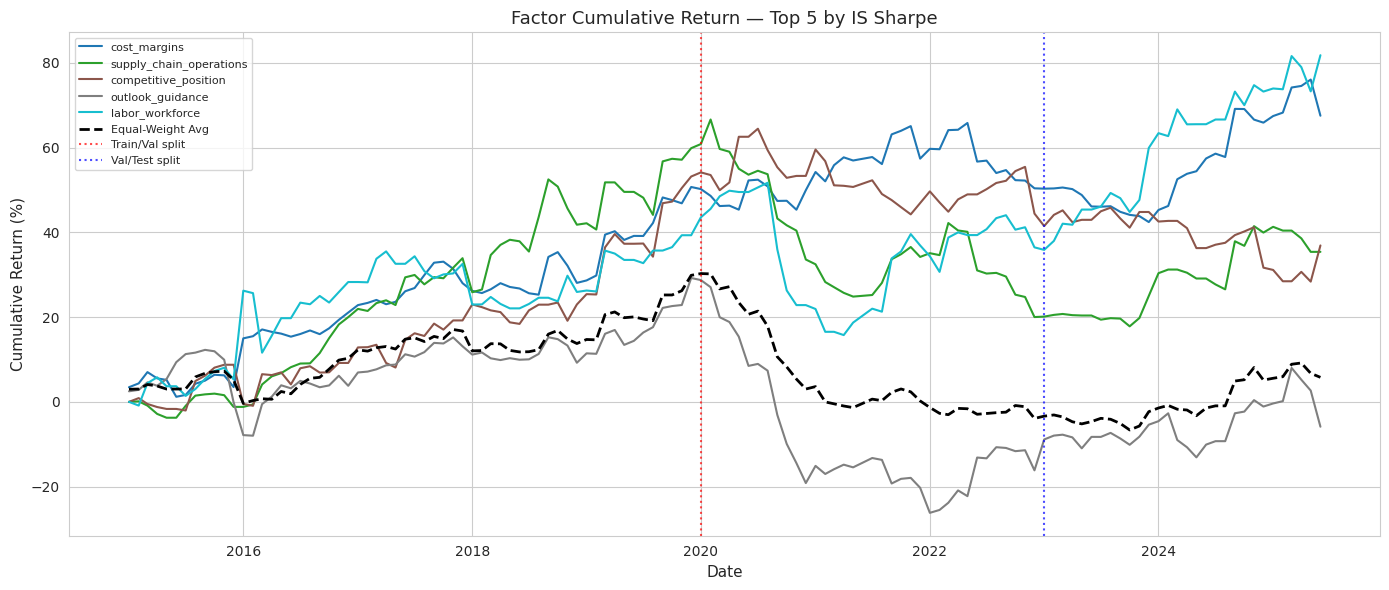

In [5]:
sns.set_style("whitegrid")

# Build monthly return series per category (full timeline)
monthly_returns = monthly.pivot_table(
    index="year_month", columns="category", values="factor_return", aggfunc="mean"
)
monthly_returns = monthly_returns.sort_index()

# Equal-weight average across all categories
monthly_returns["__EW_AVG__"] = monthly_returns.mean(axis=1)

# Convert period index to timestamps for plotting
plot_idx = monthly_returns.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(top5_categories)))
for i, cat in enumerate(top5_categories):
    if cat in monthly_returns.columns:
        cum_ret = monthly_returns[cat].fillna(0).cumsum() * 100
        ax.plot(plot_idx, cum_ret, label=cat, color=colors[i], linewidth=1.5)

# EW average
cum_ew = monthly_returns["__EW_AVG__"].fillna(0).cumsum() * 100
ax.plot(plot_idx, cum_ew, label="Equal-Weight Avg", color="black", linewidth=2, linestyle="--")

# Period boundaries
ax.axvline(TRAIN_END, color="red", linestyle=":", alpha=0.7, label="Train/Val split")
ax.axvline(VAL_END, color="blue", linestyle=":", alpha=0.7, label="Val/Test split")

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.set_title("Factor Cumulative Return — Top 5 by IS Sharpe", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Analysis 5: Rolling t-statistics

12-month and 24-month rolling t-stats for the top 5 categories. Horizontal lines at
t = +/- 1.96 (5% significance).

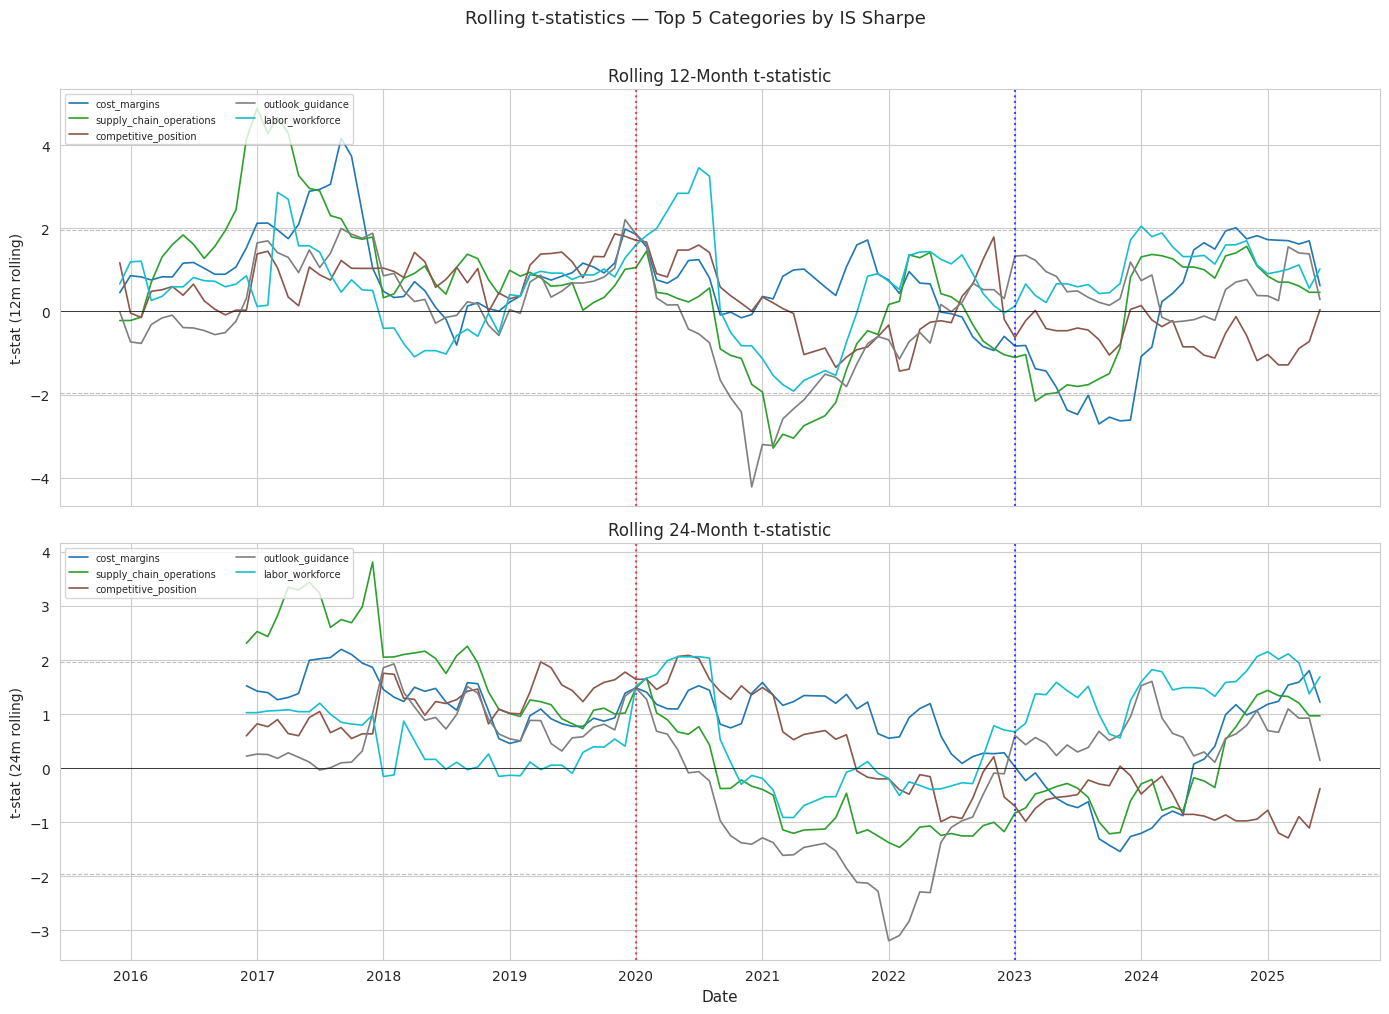

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
windows = [12, 24]
colors = plt.cm.tab10(np.linspace(0, 1, len(top5_categories)))

for ax_idx, window in enumerate(windows):
    ax = axes[ax_idx]
    for i, cat in enumerate(top5_categories):
        if cat not in monthly_returns.columns:
            continue
        series = monthly_returns[cat].fillna(0)
        rolling_mean = series.rolling(window).mean()
        rolling_std = series.rolling(window).std()
        rolling_t = rolling_mean / (rolling_std / np.sqrt(window))
        ax.plot(plot_idx, rolling_t, label=cat, color=colors[i], linewidth=1.2)

    ax.axhline(1.96, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.axhline(-1.96, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(TRAIN_END, color="red", linestyle=":", alpha=0.7)
    ax.axvline(VAL_END, color="blue", linestyle=":", alpha=0.7)
    ax.set_ylabel(f"t-stat ({window}m rolling)", fontsize=10)
    ax.set_title(f"Rolling {window}-Month t-statistic", fontsize=12)
    ax.legend(fontsize=7, loc="upper left", ncol=2)

axes[1].set_xlabel("Date", fontsize=11)
fig.suptitle("Rolling t-statistics — Top 5 Categories by IS Sharpe", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Summary & Output

In [7]:
# ── Compile results ──────────────────────────────────────────────────────
results = {
    "metadata": {
        "n_factors": len(factors_df),
        "n_filings": factor_filing_df.groupby(["ticker", "filing_date"]).ngroups,
        "n_categories": int(factors_df["category"].nunique()),
        "date_range": [
            returns_df["filing_date"].min().strftime("%Y-%m-%d"),
            returns_df["filing_date"].max().strftime("%Y-%m-%d"),
        ],
    },
    "time_split": {
        "train": "2015-01 to 2019-12",
        "val": "2020-01 to 2022-12",
        "test": "2023-01 to 2025-06",
    },
    "coverage": coverage.reset_index().to_dict(orient="records"),
    "is_ranking": is_stats.reset_index().to_dict(orient="records"),
    "oos_ranking": oos_stats.reset_index().to_dict(orient="records"),
    "top5_categories": top5_categories,
}

# Save
results_path = OUTPUT_DIR / "factor_analysis_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2, default=str)

print(f"Saved: {results_path} ({results_path.stat().st_size / 1024:.1f} KB)")

# ── Print compact summary ────────────────────────────────────────────────
print(f"\n{'=' * 70}")
print(f"  FACTOR-RETURN BACKTESTING SUMMARY")
print(f"{'=' * 70}")
print(f"\nTop 5 Categories by IS Sharpe:")
print(f"{'Category':30s}  {'IS Sharpe':>10s}  {'OOS Sharpe':>10s}  {'IS t':>6s}  {'OOS t':>6s}")
print("-" * 70)
for cat in top5_categories:
    is_s = is_stats.loc[cat, "Sharpe (ann.)"] if cat in is_stats.index else np.nan
    oos_s = oos_stats.loc[cat, "Sharpe (ann.)"] if cat in oos_stats.index else np.nan
    is_t = is_stats.loc[cat, "tstat"] if cat in is_stats.index else np.nan
    oos_t = oos_stats.loc[cat, "tstat"] if cat in oos_stats.index else np.nan
    print(f"{cat:30s}  {is_s:10.2f}  {oos_s:10.2f}  {is_t:6.2f}  {oos_t:6.2f}")

print(f"\n{'=' * 70}")

Saved: /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_2/output/factor_analysis_results.json (9.8 KB)

  FACTOR-RETURN BACKTESTING SUMMARY

Top 5 Categories by IS Sharpe:
Category                         IS Sharpe  OOS Sharpe    IS t   OOS t
----------------------------------------------------------------------
cost_margins                          1.03        0.27    2.29    0.63
supply_chain_operations               1.01       -0.40    2.17   -0.88
competitive_position                  0.97       -0.28    2.04   -0.60
outlook_guidance                      0.61       -0.51    1.37   -1.18
labor_workforce                       0.58        0.54    1.19    1.19

